In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys, os
sys.path.append('../src')
from preprocess import clean_text
print("Environment Ready")

Environment Ready


In [2]:
df = pd.read_csv('../data/Resume.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst row preview:")
print(df['Resume_str'][0][:300])

Shape: (2484, 4)

Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']

First row preview:
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commit


Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


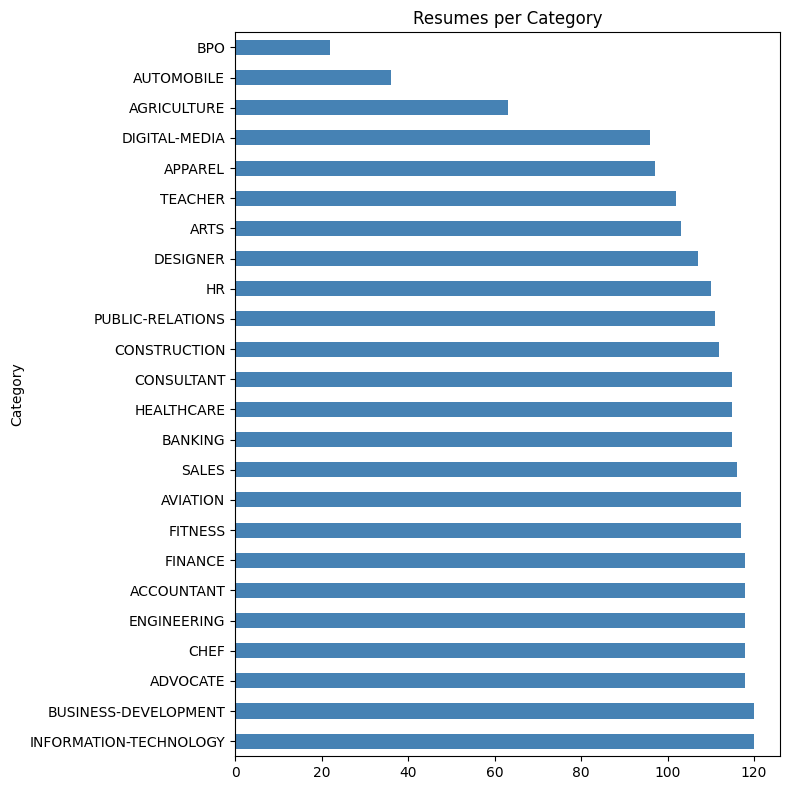

In [3]:
print(df['Category'].value_counts())
df['Category'].value_counts().plot(kind='barh', figsize=(8,8), color='steelblue')
plt.title('Resumes per Category')
plt.tight_layout()
plt.savefig('../outputs/category_dist.png', dpi=120)
plt.show()

In [4]:
df['cleaned'] = df['Resume_str'].apply(clean_text)
print("Original length:", len(df['Resume_str'][0]))
print("Cleaned length: ", len(df['cleaned'][0]))
print("\nCleaned preview:")
print(df['cleaned'][0][:300])

Original length: 5442
Cleaned length:  4258

Cleaned preview:
administrator marketing associate administrator summary dedicated customer service manager years experience hospitality customer service management respected builder leader customer focused teams strives instill shared enthusiastic commitment customer service highlights focused customer satisfaction


count    2484.000000
mean      584.216989
std       260.678939
min         0.000000
25%       476.000000
50%       547.000000
75%       674.000000
max      3543.000000
Name: word_count, dtype: float64


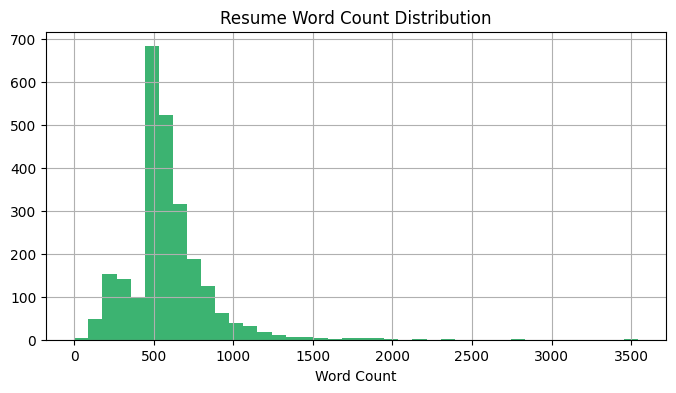

In [5]:
df['word_count'] = df['cleaned'].apply(lambda x: len(x.split()))
print(df['word_count'].describe())
df['word_count'].hist(bins=40, figsize=(8,4), color='mediumseagreen')
plt.title('Resume Word Count Distribution')
plt.xlabel('Word Count')
plt.savefig('../outputs/word_dist.png', dpi=120)
plt.show()

In [6]:
df.to_csv('../data/Resume_cleaned.csv', index=False)
print("Saved cleaned CSV to data/Resume_cleaned.csv")

Saved cleaned CSV to data/Resume_cleaned.csv
